# Q1 Formal Data Quality

Audits formal coverage, missingness, conflicts, latest-restated handling, metric flags, and H1 exclusions before interpretation.

**Analytical data as of:** 2026-08-05

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

## Quality boundary

All missing values remain null. Ratios use protected denominators, latest-restated is explicitly non-point-in-time, and every source conflict remains traceable.

In [2]:
coverage = pd.read_csv(ROOT / 'data/processed/q1_coverage_summary.csv')
missingness = pd.read_csv(ROOT / 'data/processed/q1_missingness_summary.csv')
conflicts = pd.read_csv(ROOT / 'data/processed/q1_conflict_summary.csv')
flags = pd.read_csv(ROOT / 'data/processed/q1_metric_flag_summary.csv')
waterfall = pd.read_csv(ROOT / 'data/processed/q1_h1_exclusion_waterfall.csv')
display(coverage)
display(missingness)
display(conflicts)
display(flags)
display(waterfall)

,company_id,ticker,company_name,formal_peer_group,first_fiscal_year,last_fiscal_year,company_year_rows,valid_dupont_company_years,metric_flag_count,unresolved_conflict_count,valid_dupont_transitions
0,bird,BIRD,Allbirds Inc,dtc_brand,2020,2024,5,4,2,0,3
1,figs,FIGS,FIGS Inc,dtc_brand,2020,2024,5,4,2,0,3
2,love,LOVE,Lovesac Company,dtc_brand,2018,2024,7,6,20,0,5
3,pton,PTON,Peloton Interactive Inc,dtc_brand,2019,2024,6,4,7,0,3
4,rvlv,RVLV,Revolve Group Inc,dtc_brand,2018,2024,7,6,6,0,5
5,sfix,SFIX,Stitch Fix Inc,dtc_brand,2018,2024,7,7,12,0,6
6,snbr,SNBR,Sleep Number Corp,dtc_brand,2018,2024,7,0,8,0,0
7,amzn,AMZN,Amazon.com Inc,inventory_led_ecommerce,2018,2024,7,7,1,0,6
8,byon,BYON,Bed Bath & Beyond Inc,inventory_led_ecommerce,2018,2024,7,7,22,0,6
9,chwy,CHWY,Chewy Inc,inventory_led_ecommerce,2018,2024,7,3,15,0,2


,field,missing_rows,missing_rate
0,total_debt,125,0.9124
1,inventory,50,0.3650
2,cash_and_equivalents,2,0.0146
3,capital_expenditure,0,0.0000
4,current_assets,0,0.0000
5,current_liabilities,0,0.0000
6,free_cash_flow,0,0.0000
7,net_income,0,0.0000
8,operating_cash_flow,0,0.0000
9,operating_income,0,0.0000


,conflict_severity,resolution_status,conflict_count,companies
0,high,resolved_latest_restated,176,15
1,high,resolved_tag_priority,53,13
2,low,resolved_latest_restated,482,18
3,low,resolved_tag_priority,29,10
4,medium,resolved_latest_restated,115,15
5,medium,resolved_tag_priority,20,6


,flag_code,severity,flagged_company_years,unique_companies
0,source_conflict,high,139,15
1,non_positive_average_equity,high,24,8
2,missing_prior_balance,high,15,9
3,source_conflict,medium,63,13
4,insufficient_forward_year,medium,21,21


,h1_exclusion_reason,transition_count,unique_company_count
0,invalid_dupont_transition,32,15
1,no_roe_improvement,23,14
2,eligible,21,10
3,turnaround_from_loss,20,14
4,nonpositive_prior_roe,15,9
5,next_year_not_observable,5,5


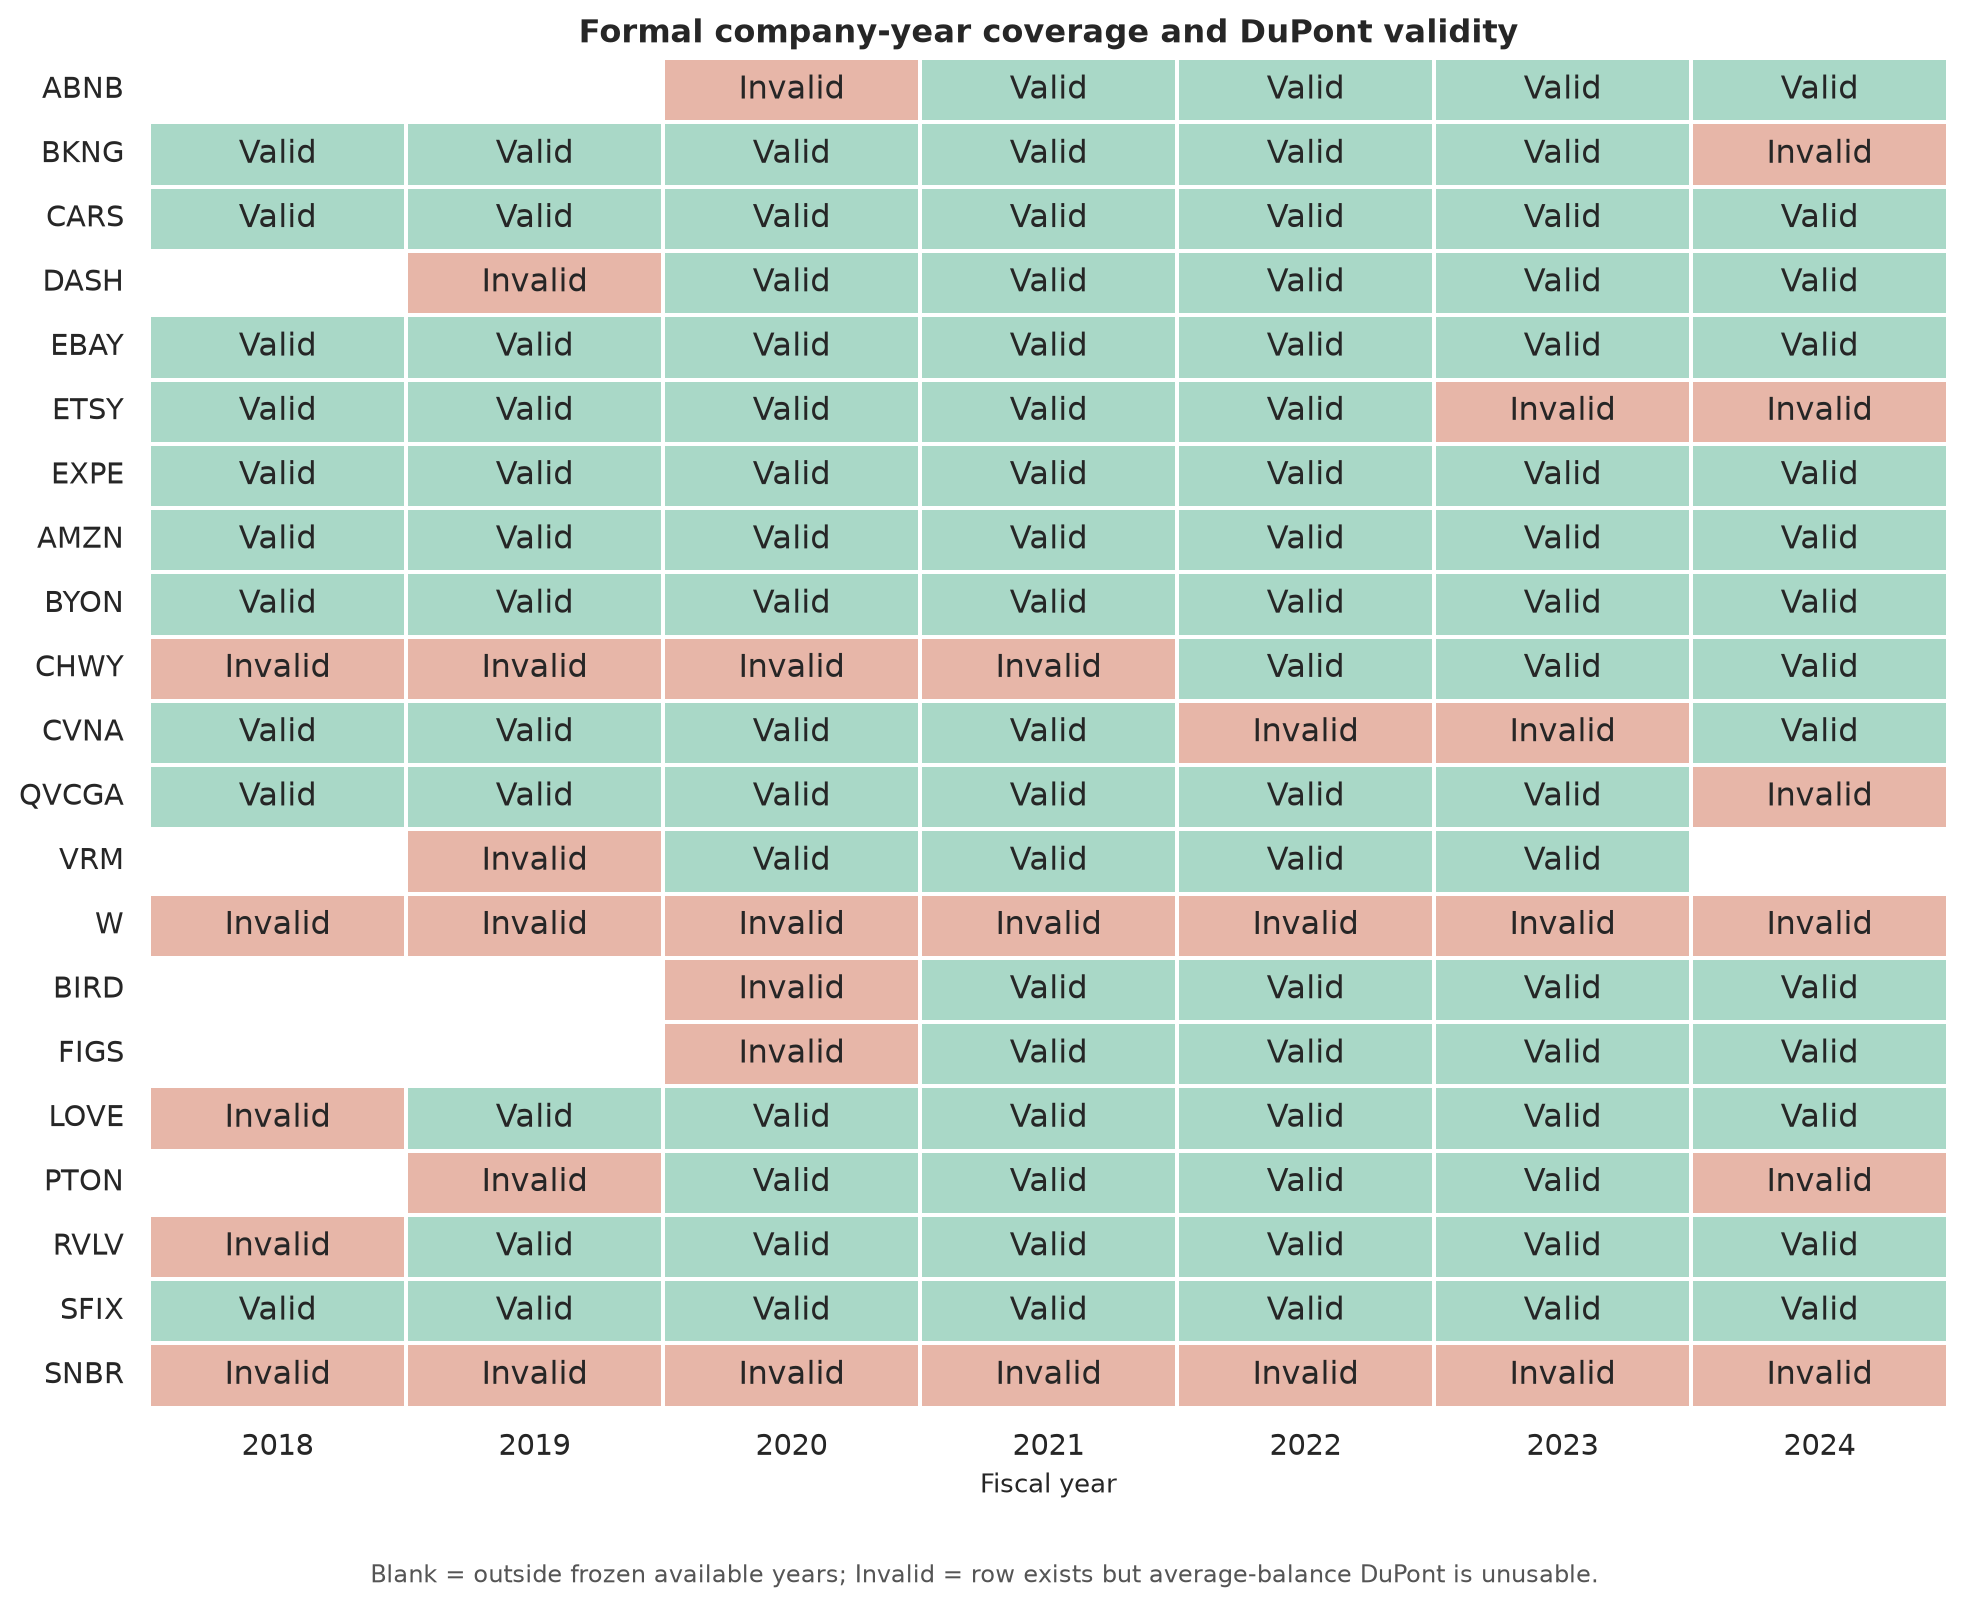

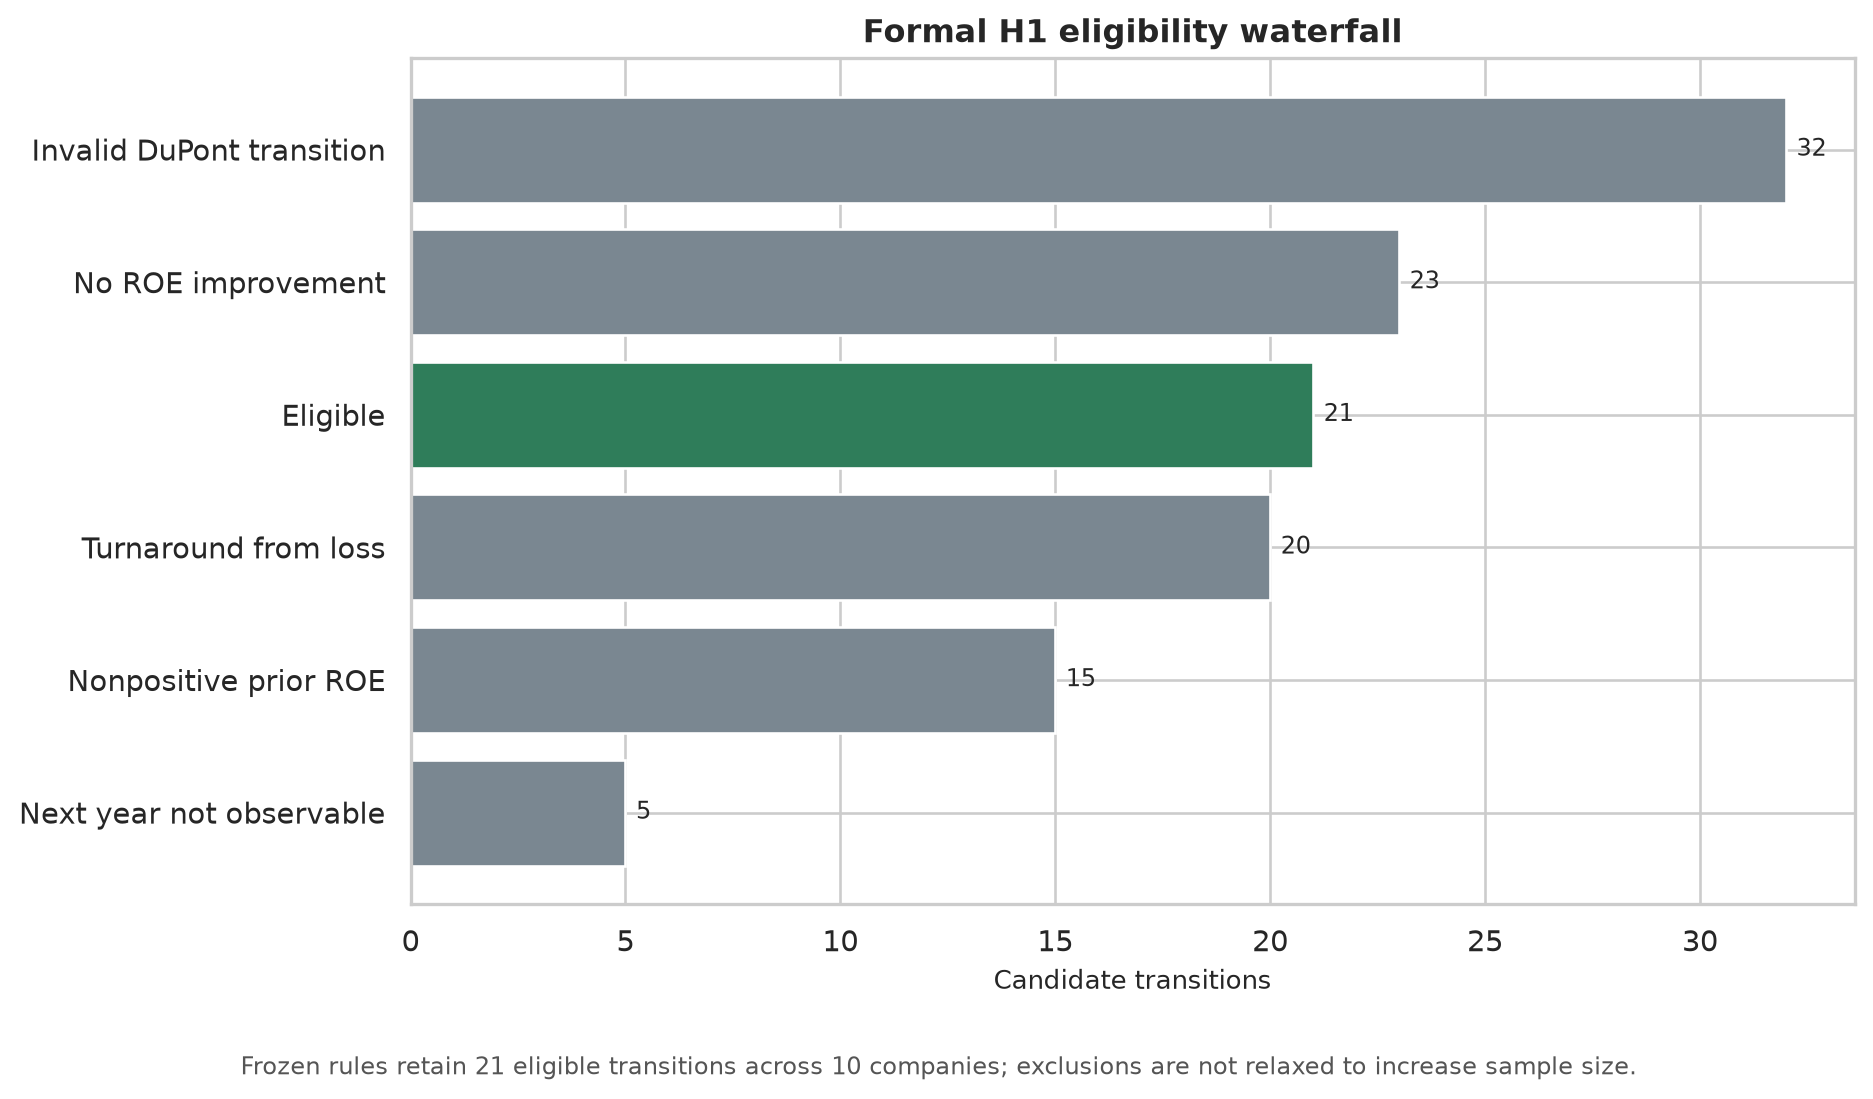

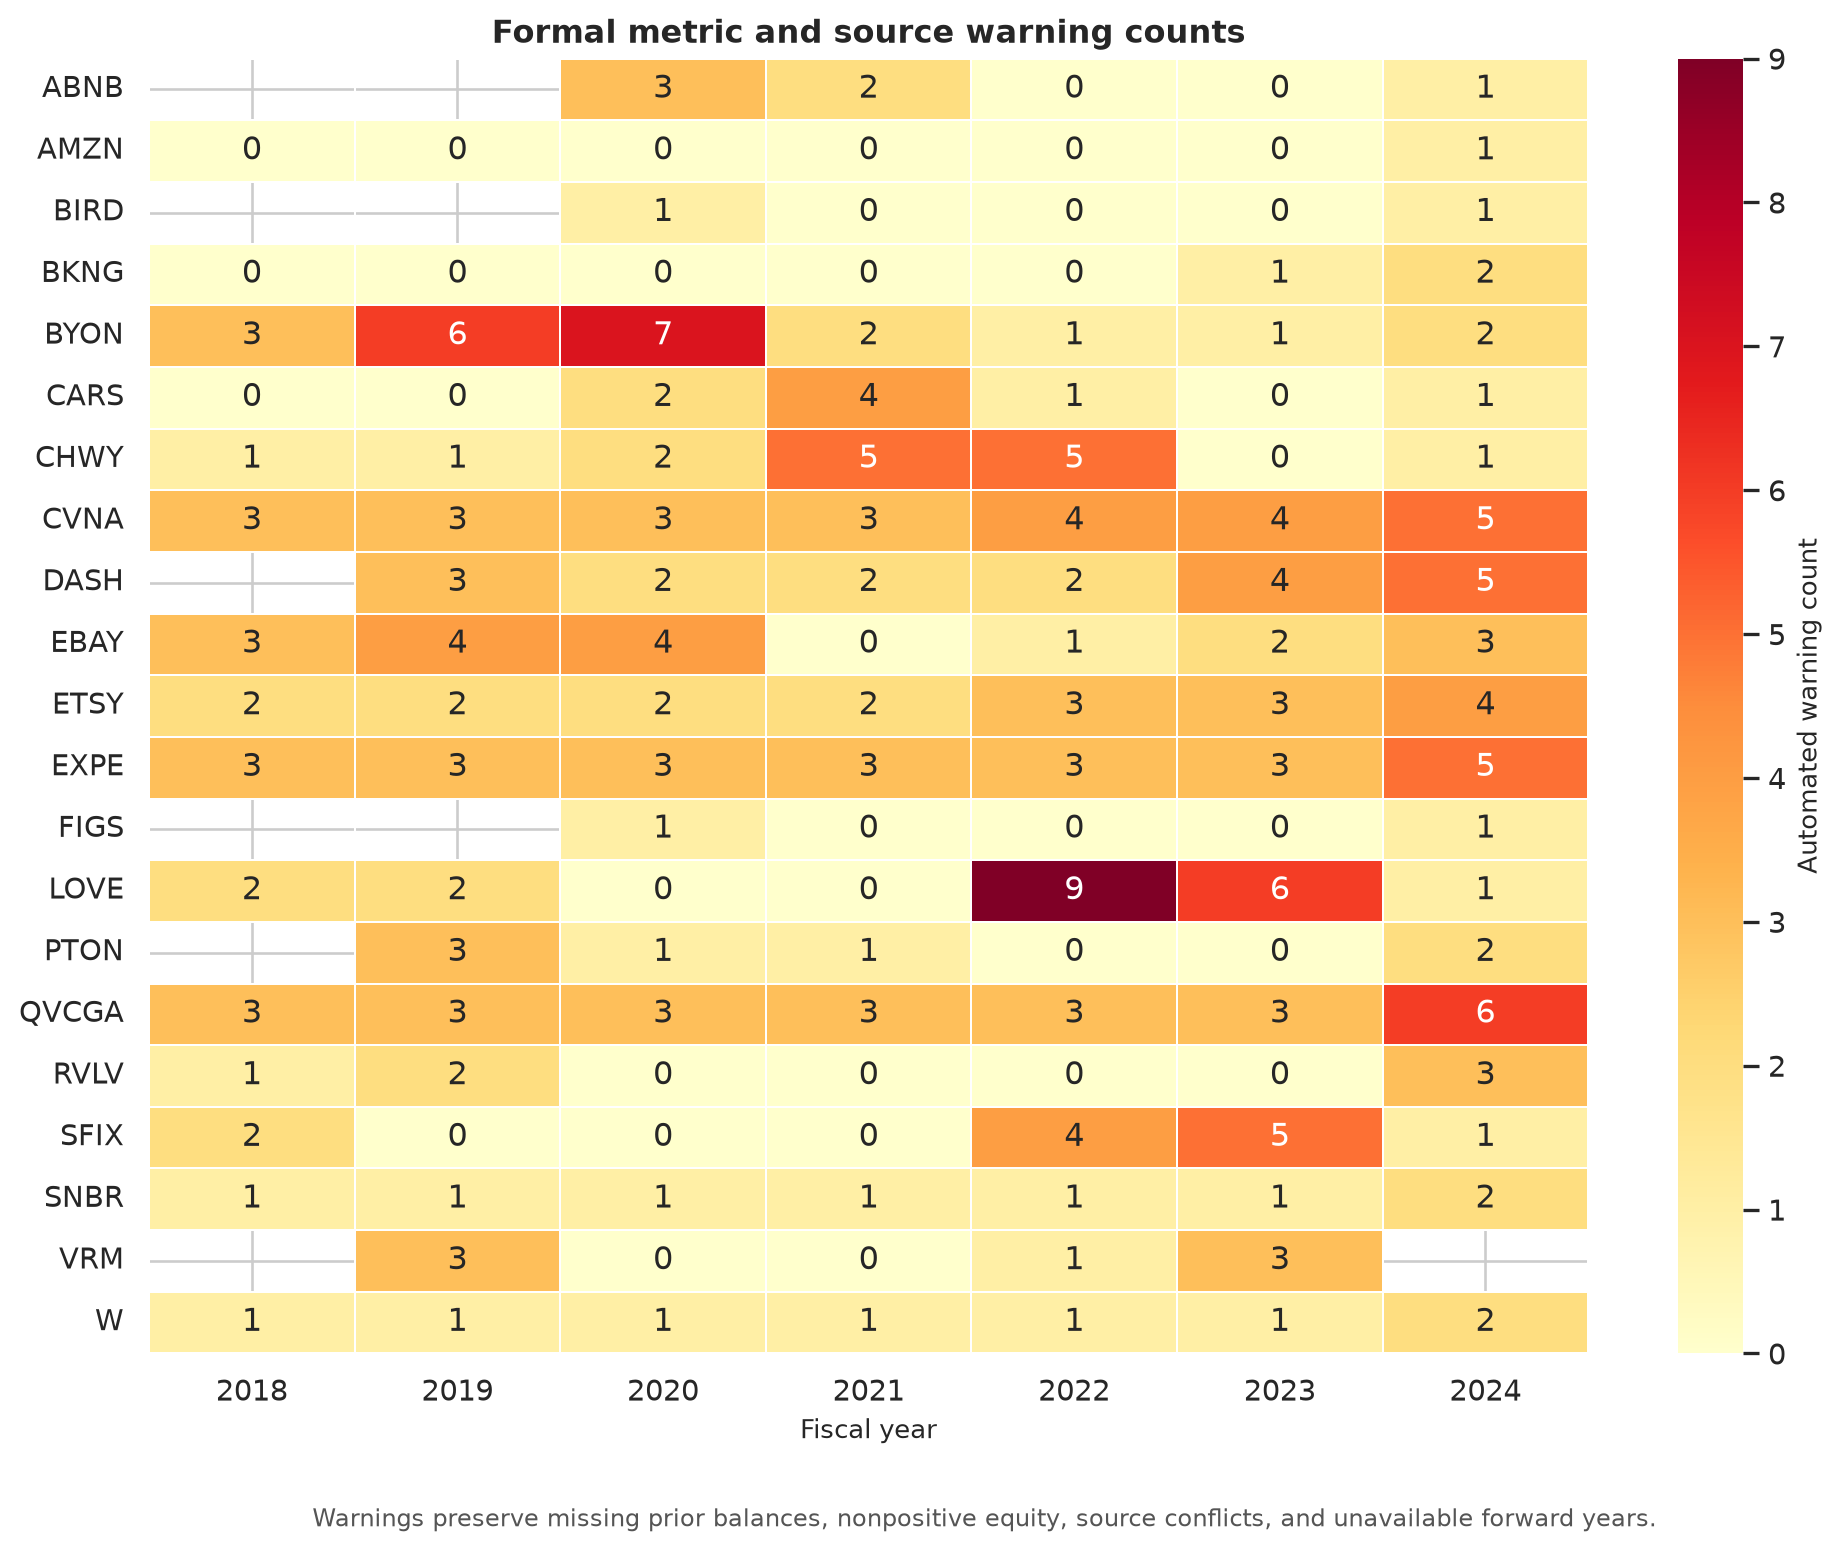

In [3]:
for name in ['01_coverage_and_dupont_validity.png', '04_h1_exclusion_waterfall.png', '06_quality_warning_matrix.png']:
    display(Image(filename=ROOT / 'docs/assets/q1' / name))